# Figuring out how to plot ERPACs

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import model
from model import generate_input_stim_xor

import vis_utils as vu
import importlib

2024-11-06 16:00:15.114694: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-06 16:00:15.122278: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-06 16:00:15.168726: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-06 16:00:15.220071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-06 16:00:15.259564: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
model_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_162018'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [3]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  0   1   4   7   9  15  22  24  25  29  41  44  53  65  70  71  74  77
  85  94 106 112 120 122 123 135 137 138 155 180 181 184 186 187 188 191
 192]


In [4]:
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, model_fname, 'IPSCs_30trall.mat'))
ipsc_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'T', 'delay', 'ipscs_sameneg', 'ipscs_samepos', 'stim_dur', 'stim_on'])

In [5]:
ipscs_samepos = ipsc_data['ipscs_samepos']
ipscs_sameneg = ipsc_data['ipscs_sameneg']
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]

print(ipscs_samepos.shape)
print(ipscs_sameneg.shape)
print(T)
print(stim_on)
print(stim_dur)
print(delay)

(200, 41100, 30)
(200, 41100, 30)
411
31
50
150


In [6]:
settings = {
        'T': T, # trial duration (in steps)
        'stim_on': stim_on, # input stim onset (in steps)
        'stim_dur': stim_dur, # input stim duration (in steps)
        'delay': delay, # delay b/w the two stimuli (in steps)
        }

print(f'T: {settings["T"]}')
print(f'stim_on: {settings["stim_on"]}')
print(f'stim_dur: {settings["stim_dur"]}')
print(f'delay: {settings["delay"]}')

T: 411
stim_on: 31
stim_dur: 50
delay: 150


In [7]:
fs_rate = 200
fs_spk = 20000

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

In [8]:
import tensorpac
import vis_utils as vu

In [ ]:
trial_labels = ['+1','-1']
neuron_labels = ['exc','inh']
ipscs = [ipscs_samepos, ipscs_sameneg]

# calculate all erpacs and save
all_rp_objs = {}
all_erpacs = {}
for i, ipsc in enumerate(ipscs): # +1 and -1 trials
    rp_objs = {}
    erpacs = {}
    for j, neuron_inds in enumerate([exc_ind, inh_ind]):
        rp_obj, erpac = vu.calculate_erpac(ipsc, fs_spk, neuron_inds, plot=0,
                                            f_pha=[4, 8], f_amp=(30, 200, 2, 1), dcomplex='hilbert', cycle=(3,6), width=7, method='circular')
        rp_objs[neuron_labels[j]] = rp_obj
        erpacs[neuron_labels[j]] = erpac
    all_rp_objs[trial_labels[i]] = rp_objs
    all_erpacs[trial_labels[i]] = erpacs

In [27]:
# import scipy.signal

def downsample(signal, fs_high, fs_low):
    '''
    Downsample signal from high to low sampling rate
    '''
    if len(signal.shape) == 1:
        signal = signal[np.newaxis,:]
    
    for i in range(signal.shape[0]):
        this_signal = signal[i,:]
        t_high = np.arange(0, len(this_signal)/fs_high, 1/fs_high)
        num_samples = int(len(t_high) * fs_low / fs_high)
        signal_low = scipy.signal.resample(this_signal, num_samples)
        if i == 0:
            all_signal_low = np.zeros((signal.shape[0], signal_low.shape[0]))
        all_signal_low[i,:] = signal_low

    return all_signal_low

In [ ]:
f_pha=[4, 8]
f_amp=(30, 200, 2, 1)
dcomplex='hilbert'
cycle=(3,6)
width=7
method='circular'

In [17]:
ipscs_samepos.shape

(200, 41100, 30)

Event Related PAC object defined
    Extract phases (n_pha=1) and amplitudes (n_amps=168)
    Compute ERPAC (Voytek et al. 2013)
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/tensorpac/methods/meth_erpac.py:38: RuntimeWarning: divide by zero encountered in divide
  cov /= np.einsum(st, s_x, s_y)
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/tensorpac/methods/meth_erpac.py:38: RuntimeWarning: invalid value encountered in divide
  cov /= np.einsum(st, s_x, s_y)
    Correct p-values for multiple-comparisons using fdr correction of MNE-Python


<Axes: title={'center': 'ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

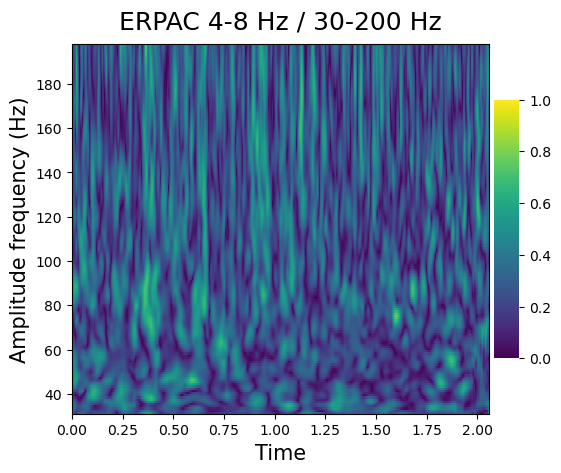

In [41]:
f_amp=(30, 200, 2, 1)

data = ipscs_samepos[0,:,:].squeeze().T  # trials x times
# data = downsample(data, fs_spk, 1000)

times = np.arange(data.shape[1])
rp_obj = tensorpac.EventRelatedPac(f_pha=f_pha, f_amp=f_amp, dcomplex=dcomplex, 
                    cycle=cycle, width=width)
erpac = rp_obj.filterfit(fs_spk, data, method=method)
rp_obj.pacplot(erpac.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

(168, 41100)


<Axes: title={'center': 'Significant ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

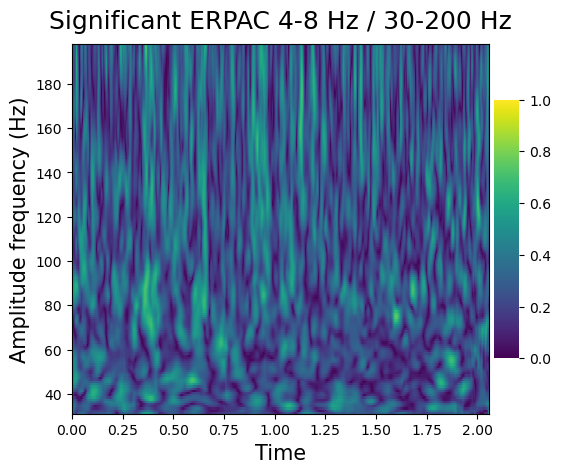

In [42]:
pvalues = rp_obj.pvalues.squeeze()
print(pvalues.shape)

erpac_sig = erpac.copy().squeeze()
rows, cols = np.where(pvalues > .05)
erpac_sig[rows, cols] = np.nan
rp_obj.pacplot(erpac_sig.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'Significant ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

Event Related PAC object defined
    Extract phases (n_pha=1) and amplitudes (n_amps=168)


    Compute ERPAC (Voytek et al. 2013)
    Correct p-values for multiple-comparisons using fdr correction of MNE-Python


<Axes: title={'center': 'Downsampled to 10000Hz ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

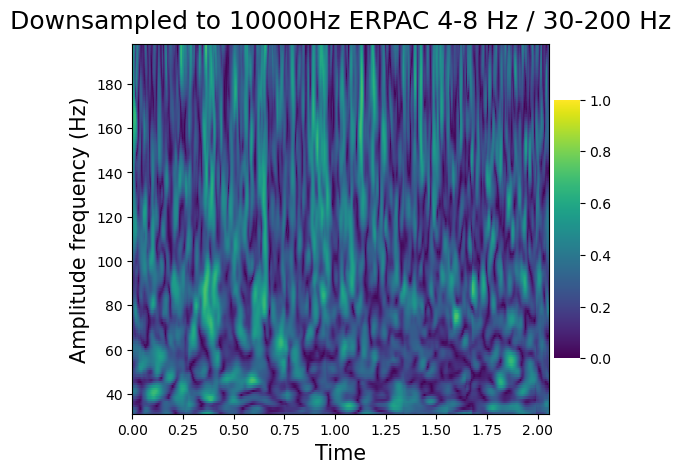

In [43]:
# downsample

new_fs = 10000

f_amp=(30, 200, 2, 1)

data = ipscs_samepos[0,:,:].squeeze().T  # trials x times (44k)
data = downsample(data, fs_spk, new_fs)

times = np.arange(data.shape[1])
rp_obj = tensorpac.EventRelatedPac(f_pha=f_pha, f_amp=f_amp, dcomplex=dcomplex, 
                    cycle=cycle, width=width)
erpac = rp_obj.filterfit(new_fs, data, method=method, mcp='fdr')
rp_obj.pacplot(erpac.squeeze(), times/new_fs, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'Downsampled to {new_fs}Hz ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

(168, 20550)


<Axes: title={'center': 'Significant downsampled ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

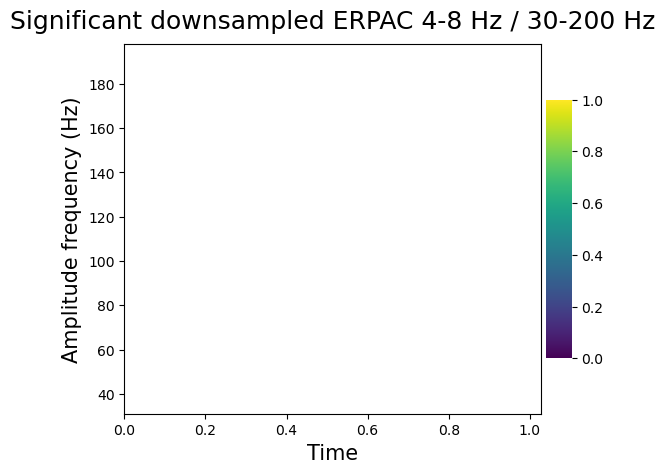

In [44]:
pvalues = rp_obj.pvalues.squeeze()
print(pvalues.shape)

erpac_sig = erpac.copy().squeeze()
rows, cols = np.where(pvalues > .05)
erpac_sig[rows, cols] = np.nan
rp_obj.pacplot(erpac_sig.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'Significant downsampled ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

<Axes: title={'center': 'ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

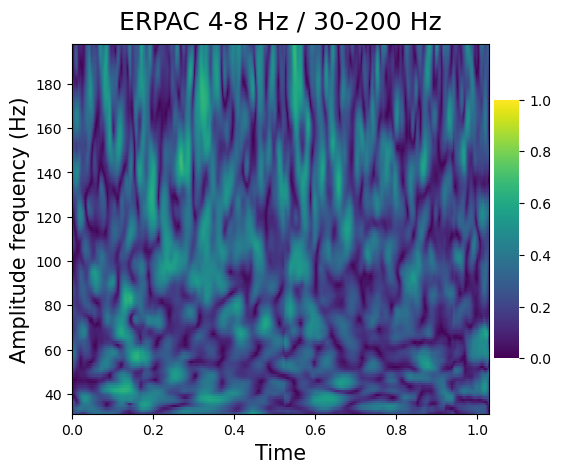

In [ ]:
f_amp=(30, 200, 2, 1)

data = ipscs_samepos[0,:,:].squeeze().T  # trials x times (44k)
data = downsample(data, fs_spk, 10000)

times = np.arange(data.shape[1])
rp_obj = tensorpac.EventRelatedPac(f_pha=f_pha, f_amp=f_amp, dcomplex=dcomplex, 
                    cycle=cycle, width=width)
erpac = rp_obj.filterfit(fs_spk, data, method=method, mcp='bonferroni')
rp_obj.pacplot(erpac.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

(168, 20550)


<Axes: title={'center': 'ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

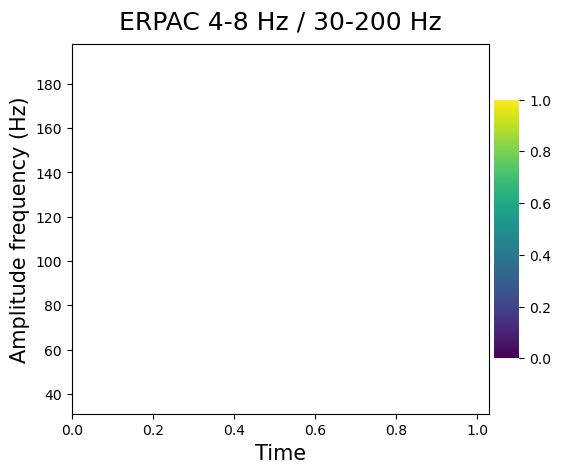

In [40]:
pvalues = rp_obj.pvalues.squeeze()
print(pvalues.shape)

erpac_sig = erpac.copy().squeeze()
rows, cols = np.where(pvalues > .05)
erpac_sig[rows, cols] = np.nan
rp_obj.pacplot(erpac_sig.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

Event Related PAC object defined
    Extract phases (n_pha=1) and amplitudes (n_amps=168)
    Compute ERPAC (Voytek et al. 2013)
    Correct p-values for multiple-comparisons using fdr correction of MNE-Python


<Axes: title={'center': 'ERPAC 4-8 Hz / 30-200 Hz'}, xlabel='Time', ylabel='Amplitude frequency (Hz)'>

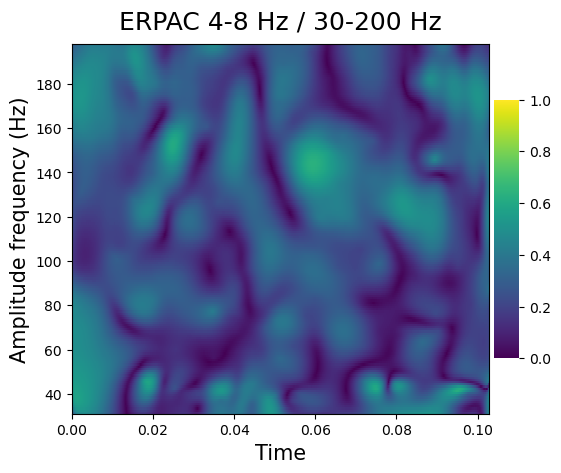

In [31]:
f_amp=(30, 200, 2, 1)

data = ipscs_samepos[0,:,:].squeeze().T  # trials x times (44k)
data = downsample(data, fs_spk, 1000) # 30 x 2055 now

times = np.arange(data.shape[1])
rp_obj = tensorpac.EventRelatedPac(f_pha=f_pha, f_amp=f_amp, dcomplex=dcomplex, 
                    cycle=cycle, width=width)
erpac = rp_obj.filterfit(fs_spk, data, method=method)
rp_obj.pacplot(erpac.squeeze(), times/fs_spk, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'ERPAC {f_pha[0]}-{f_pha[1]} Hz / {f_amp[0]}-{f_amp[1]} Hz',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)

In [ ]:
times = np.arange(ipscs.shape[1])
data = np.nanmean(ipscs[neuron_inds,:,:], axis=0).squeeze().T # neuron mean, trials x times, transpose to get trials x times
print(data.shape)
# n_trials = data.shape[0]
# pdb.set_trace()

rp_obj = tensorpac.EventRelatedPac(f_pha=f_pha, f_amp=f_amp, dcomplex=dcomplex, 
                    cycle=cycle, width=width)
erpac = rp_obj.filterfit(fs, data, method=method)

plt.figure(figsize=(8, 6))
rp_obj.pacplot(erpac.squeeze(), times/fs, rp_obj.yvec, xlabel='Time',
            ylabel='Amplitude frequency (Hz)',
            title=f'ERPAC for theta ({f_pha[0]}-{f_pha[1]}Hz) phase, {neuron_label} neurons, {trial_label}',
            fz_labels=15, fz_title=18, vmin=0, vmax=1)
plt.axvline(settings['stim_on']/fs*100, color='r', linestyle='--')
plt.axvline((settings['stim_on']+settings['stim_dur'])/fs*100, color='r', linestyle='--')
plt.axvline((settings['stim_on']+settings['stim_dur']+settings['delay'])/fs*100, color='r', linestyle='--')
plt.axvline((settings['stim_on']+2*settings['stim_dur']+settings['delay'])/fs*100, color='r', linestyle='--')
plt.show()